<a href="https://colab.research.google.com/github/FranexeArg/Trabajo-Final-Curso-de-Data-Science-UTN-BA/blob/main/Trabajo_Final_Costa_Francisco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto de Data Science — Trabajo Final

# 1. Selección del dataset:

El Dataset seleccionado es 2024 Trayectoria agregada que es una base de  datos de trayectorias educativas de la secretaría educación de la nación correspondiente al año 2024. La cual se puede conseguir del siguiente repositorio https://ministeriodeeducaciondelanacion-my.sharepoint.com/:x:/g/personal/santiago_pomeranz_educacion_gob_ar/IQDv_L6PhEMySbttY_PhSaWXAcTEELnlH00hEO653gw2Jnw?rtime=q7jUaNfs3kg

En relación a esta base de datos se nos plantean las siguientes preguntas:

*   ¿Cómo se comportan los egresados del país teniendo en cuenta las provincias y el género?
*   ¿Cuál es la distribución de egresados por provincia?
*   ¿Cuál es la diferencia entre varones y mujeres egresados?
*   ¿Cuáles son los departamentos con mayor peso en egresados cada provincia?

# 1.1 Carga de librerías de trabajo

In [ ]:
#Librerías a utilizar

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 2.Carga del dataset

In [ ]:
df_trayectoria = pd.read_csv('/content/drive/MyDrive/CursoUTN/2024 Trayectoria - agregada(in).csv', encoding='latin1', sep=';')

# 3.Exploración de los datos



In [ ]:
#Información del dataset
df_trayectoria.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1209 entries, 0 to 1208
Columns: 288 entries, provincia to secundaria_m_egresados
dtypes: object(288)
memory usage: 2.7+ MB


In [ ]:
#Tipo de datos del dataset
df_trayectoria.dtypes

,0
provincia,object
Departamento,object
sector,object
ambito,object
inicial_1,object
...,...
m_otros_20,object
primaria_egresados,object
primaria_m_egresados,object
secundaria_egresados,object


In [ ]:
#Dimensiones del dataset
df_trayectoria.shape

(1209, 288)

In [ ]:
#Primeros registros del dataset
df_trayectoria.head()

,provincia,Departamento,sector,ambito,inicial_1,inicial_2,inicial_3,inicial_4,inicial_5,inicial_6,...,m_otros_9,m_otros_10,m_otros_11,m_otros_12,m_otros_1314,m_otros_20,primaria_egresados,primaria_m_egresados,secundaria_egresados,secundaria_m_egresados
0,Buenos Aires,25 DE MAYO,Estatal,Rural,95,92,90,97,109,103,...,0,0,0,0,,,102,52,83,29
1,Buenos Aires,25 DE MAYO,Estatal,Urbano,286,345,351,320,305,324,...,0,0,0,0,0,,326,173,209,126
2,Buenos Aires,25 DE MAYO,Privado,Urbano,138,147,142,136,152,132,...,0,0,0,0,,,131,60,111,62
3,Buenos Aires,9 DE JULIO,Estatal,Rural,123,82,135,138,120,113,...,0,0,0,0,0,,113,54,72,35
4,Buenos Aires,9 DE JULIO,Estatal,Urbano,502,524,544,520,503,522,...,0,0,0,0,0,,527,269,350,189


### Diccionario de Variables



*   Provincia: Nominal, Provincia argentina a la que corresponde.
*   Departamento: Nominal, Departamento de la provincia al que corresponde el dato.
*   Sector: Nominal, sector de gestión de la educación.
*   Ámbito: ámbito educativo al que pertenece el dato puede ser rural como urbano.
*   inicial_1: numérico, matrícula inicial de 1er año corrido.
*   inicial_2: numérico, matrícula inicial de 2do año corrido.
*   inicial_3: numérico, matrícula inicial de 3er año corrido.
*   inicial_4: numérico, matrícula inicial 4to año corrido.
*   inicial_5: numérico, matrícula inicial 5to año corrido.
*   inicial_6: numérico, matrícula inicial 6to año corrido.
*   inicial_7: numérico, matrícula inicial 7mo año corrido.
*   inicial_8: numérico, matrícula inicial 8vo año corrido.
*   inicial_9: numérico, matrícula inicial de 9no año corrido.
*   inicial_10: numérico, matrícula inicial de 10mo año corrido.
*   inicial_11: numérico, matrícula inicial de 11 año corrido.
*   inicial_12: numérico, matrícula inicial de 12 año corrido.
*   inicial_1314: numérico, matrícula inicial de 1314 año corrido.
*   inicial_20: numérico, matrícula inicial de organización no graduada.
*   m_inicial_1: numérico, matrícula inicial mujeres _1 año corrido.
*   m_inicial_2: numérico,  matrícula inicial mujeres _2 año corrido.
*   m_inicial_3: numérico,  matrícula inicial mujeres _3 año corrido.
*   m_inicial_4: numérico,  matrícula inicial mujeres _4 año corrido.
*   m_inicial_5: numérico,  matrícula inicial mujeres _5 año corrido.
*    m_inicial_6: numérico,  matrícula inicial mujeres _6 año corrido.
*    m_inicial_7: numérico,  matrícula inicial mujeres _7 año corrido.
*    m_inicial_8: numérico,  matrícula inicial mujeres _8 año corrido.
*    m_inicial_9: numérico,  matrícula inicial mujeres _9 año corrido.
* m_inicial_10: numérico,  matrícula inicial mujeres _10 año corrido.
* m_inicial_11: numérico,  matrícula inicial mujeres _11 año corrido.
* m_inicial_12: numérico,  matrícula inicial mujeres _12 año corrido.
* m_inicial_1314: numérico,  matrícula inicial mujeres _1314 año corrido.
* m_inicial_20: numérico,  matrícula inicial mujeres de organización no graduada.
* entrados_1: numérico,  matrícula entrados _1 año corrido.
* entrados_2: numérico,  matrícula entrados _2 año corrido.
* entrados_3: numérico,  matrícula entrados _3 año corrido.
* entrados_4: numérico,  matrícula entrados _4 año corrido.
* entrados_5: numérico,  matrícula entrados _5 año corrido.
* entrados_6: numérico,  matrícula entrados _6 año corrido.
* entrados_7: numérico,  matrícula entrados _7 año corrido.
* entrados_8: numérico,  matrícula entrados _8 año corrido.
* entrados_9: numérico,  matrícula entrados _9 año corrido.
* entrados_10: numérico,  matrícula entrados _10 año corrido.
* entrados_11: numérico,  matrícula entrados _11 año corrido.
* entrados_12: numérico,  matrícula entrados _12 año corrido.
* entrados_1314: numérico,  matrícula entrados _1314 año corrido.
* entrados_20: numérico,  matrícula de entrados organización no graduada.
* m_entrados_1: numérico, matrícula entrados mujeres _1 año corrido.
* m_entrados_2: numérico, matrícula entrados mujeres _2 año corrido.
* m_entrados_3: numérico, matrícula entrados mujeres _3 año corrido.
* m_entrados_4: numérico, matrícula entrados mujeres _4 año corrido.
* m_entrados_5: numérico, matrícula entrados mujeres _5 año corrido.
* m_entrados_6: numérico, matrícula entrados mujeres _6 año corrido.
* m_entrados_7: numérico, matrícula entrados mujeres _7 año corrido.
* m_entrados_8: numérico, matrícula entrados mujeres _8 año corrido.
* m_entrados_9: numérico, matrícula entrados mujeres _9 año corrido.
* m_entrados_10: numérico, matrícula entrados mujeres _10 año corrido.
* m_entrados_11: numérico, matrícula entrados mujeres _11 año corrido.
* m_entrados_12: numérico, matrícula entrados mujeres _12 año corrido.
* m_entrados_1314: numérico, matrícula entrados mujeres _1314 año corrido.
* m_entrados_20: matrícula entrados mujeres de organización no graduada.
* scp_1: numérico, salidos con pase _1 año corrido.
* scp_2: numérico, salidos con pase _2 año corrido.
* scp_3: numérico, salidos con pase _3 año corrido.
* scp_4: numérico, salidos con pase _4 año corrido.
* scp_5: numérico, salidos con pase _5 año corrido.
* scp_6: numérico, salidos con pase _6 año corrido.
* scp_7: numérico, salidos con pase _7 año corrido.
* scp_8: numérico, salidos con pase _8 año corrido.
* scp_9: numérico, salidos con pase _9 año corrido.
* scp_10: numérico, salidos con pase _10 año corrido.
* scp_11: numérico, salidos con pase _12 año corrido.
* scp_12: numérico, salidos con pase _12 año corrido.
* scp_1314: numérico, salidos con pase _1314 año corrido.
* scp_20: numérico, salidos con pase de organización no graduada.
* m_scp_1: numérico, salidos con pase mujeres _1 año corrido.
* m_scp_2: numérico, salidos con pase mujeres _2 año corrido.
* m_scp_3: numérico, salidos con pase mujeres _3 año corrido.
* m_scp_4: numérico, salidos con pase mujeres _4 año corrido.
* m_scp_5: numérico, salidos con pase mujeres _5 año corrido.
* m_scp_6: numérico, salidos con pase mujeres _6 año corrido.
* m_scp_7: numérico, salidos con pase mujeres _7 año corrido.
* m_scp_8: numérico, salidos con pase mujeres _8 año corrido.
* m_scp_9: numérico, salidos con pase mujeres _9 año corrido.
* m_scp_10: numérico, salidos con pase mujeres _10 año corrido.
* m_scp_11: numérico, salidos con pase mujeres _11 año corrido.
* m_scp_12: numérico, salidos con pase mujeres _12 año corrido.
* m_scp_1314: numérico, salidos con pase mujeres _1314 año corrido.
* m_scp_20: numérico, salidos con pase mujeres de organización no graduada.
* ssp_1: numérico, salidos sin pase _1 año corrido.
* ssp_2: numérico, salidos sin pase _2 año corrido.
* ssp_3: numérico, salidos sin pase _3 año corrido.
* ssp_4: numérico, salidos sin pase _4 año corrido.
* ssp_5: numérico, salidos sin pase _5 año corrido.
* ssp_6: numérico, salidos sin pase _6 año corrido.
* ssp_7: numérico, salidos sin pase _7 año corrido.
* ssp_8: numérico, salidos sin pase _8 año corrido.
* ssp_9: numérico, salidos sin pase _9 año corrido.
* ssp_10: numérico, salidos sin pase _10 año corrido.
* ssp_11: numérico, salidos sin pase _11 año corrido.
* ssp_12: numérico, salidos sin pase _12 año corrido.
* ssp_1314: numérico, salidos sin pase _1314 año corrido.
* ssp_20: numérico, salidos sin pase de organización no graduada.
* m_ssp_1: numérico, salidos sin pase mujeres _1 año corrido.
* m_ssp_2: numérico, salidos sin pase mujeres _2 año corrido.
* m_ssp_3: numérico, salidos sin pase mujeres _3 año corrido.
* m_ssp_4: numérico, salidos sin pase mujeres _4 año corrido.
* m_ssp_5: numérico, salidos sin pase mujeres _5 año corrido.
* m_ssp_6: numérico, salidos sin pase mujeres _6 año corrido.
* m_ssp_7: numérico, salidos sin pase mujeres _7 año corrido.
* m_ssp_8: numérico, salidos sin pase mujeres _8 año corrido.
* m_ssp_9: numérico, salidos sin pase mujeres _9 año corrido.
* m_ssp_10: numérico, salidos sin pase mujeres _10 año corrido.
* m_ssp_11: numérico, salidos sin pase mujeres _11 año corrido.
* m_ssp_12: numérico, salidos sin pase mujeres _12 año corrido.
* m_ssp_1314: numérico, salidos sin pase mujeres _1314 año corrido.
* m_ssp_20: numérico, salidos sin pase mujeres de organización no graduada.
* ultimo_1: numérico, matrícula ultimo día de clases _1 año corrido.
* ultimo_2: numérico, matrícula ultimo día de clases _2 año corrido.
* ultimo_3: numérico, matrícula ultimo día de clases _3 año corrido.
* ultimo_4: numérico, matrícula ultimo día de clases _4 año corrido.
* ultimo_5: numérico, matrícula ultimo día de clases _5 año corrido.
* ultimo_6: numérico, matrícula ultimo día de clases _6 año corrido.
* ultimo_7: numérico, matrícula ultimo día de clases _7 año corrido.
* ultimo_8: numérico, matrícula ultimo día de clases _8 año corrido.
* ultimo_9: numérico, matrícula ultimo día de clases _9 año corrido.
* ultimo_10: numérico, matrícula ultimo día de clases _10 año corrido.
* ultimo_11: numérico, matrícula ultimo día de clases _11 año corrido.
* ultimo_12: numérico, matrícula ultimo día de clases _12 año corrido.
* ultimo_1314: numérico, matrícula ultimo día de clases _1314 año corrido.
* ultimo_20: numérico, matrícula ultimo día de clases de organización no graduada.
* m_ultimo_1: numérico, matrícula ultimo día de clases mujeres _1 año corrido.
* m_ultimo_2: numérico, matrícula ultimo día de clases mujeres _2 año corrido.
* m_ultimo_3: numérico, matrícula ultimo día de clases mujeres _3 año corrido.
* m_ultimo_4: numérico, matrícula ultimo día de clases mujeres _4 año corrido.
* m_ultimo_5: numérico, matrícula ultimo día de clases mujeres _5 año corrido.
* m_ultimo_6: numérico, matrícula ultimo día de clases mujeres _6 año corrido.
* m_ultimo_7: numérico, matrícula ultimo día de clases mujeres _7 año corrido.
* m_ultimo_8: numérico, matrícula ultimo día de clases mujeres _8 año corrido.
* m_ultimo_9: numérico, matrícula ultimo día de clases mujeres _9 año corrido.
* m_ultimo_10: numérico, matrícula ultimo día de clases mujeres _10 año corrido.
* m_ultimo_11: numérico, matrícula ultimo día de clases mujeres _11 año corrido.
* m_ultimo_12: numérico, matrícula ultimo día de clases mujeres _12 año corrido.
* m_ultimo_1314: numérico, matrícula ultimo día de clases mujeres _1314 año corrido.
* m_ultimo_20: numérico, matrícula ultimo día de clases mujeres de organización no graduada.
* promovidos_1: numérico, promovidos_1 año corrido.
* promovidos_2: numérico, promovidos_2 año corrido.
* promovidos_3: numérico, promovidos_3 año corrido.
* promovidos_4: numérico, promovidos_4 año corrido.
* promovidos_5: numérico, promovidos_5 año corrido.
* promovidos_6: numérico, promovidos_6 año corrido.
* promovidos_7: numérico, promovidos_7 año corrido.
* promovidos_8: numérico, promovidos_8 año corrido.
* promovidos_9: numérico, promovidos_9 año corrido.
* promovidos_10: numérico, promovidos_10 año corrido.
* promovidos_11: numérico, promovidos_11 año corrido.
* promovidos_12: numérico, promovidos_12 año corrido.
* promovidos_1314: numérico, promovidos_1314 año corrido.
* promovidos_20: numérico, promovidos de organización no graduada.
* m_promovidos_1: numérico, promovidos mujeres 1 año corrido.
* m_promovidos_2: numérico, promovidos mujeres 2 año corrido.
* m_promovidos_3: numérico, promovidos mujeres 3 año corrido.
* m_promovidos_4: numérico, promovidos mujeres 4 año corrido.
* m_promovidos_5: numérico, promovidos mujeres 5 año corrido.
* m_promovidos_6: numérico, promovidos mujeres 6 año corrido.
* m_promovidos_7: numérico, promovidos mujeres 7 año corrido.
* m_promovidos_8: numérico, promovidos mujeres 8 año corrido.
* m_promovidos_9: numérico, promovidos mujeres 9 año corrido.
* m_promovidos_10: numérico, promovidos mujeres 10 año corrido.
* m_promovidos_11: numérico, promovidos mujeres 11 año corrido.
* m_promovidos_12: numérico, promovidos mujeres 12 año corrido.
* m_promovidos_1314: numérico, promovidos mujeres de organización no graduada.
* promovidos_ex_1: numérico, promovidos con exámen 1 año corrido.
* promovidos_ex_2: numérico, promovidos con exámen 2 año corrido.
* promovidos_ex_3: numérico, promovidos con exámen 3 año corrido.
* promovidos_ex_4: numérico, promovidos con exámen 4 año corrido.
* promovidos_ex_5: numérico, promovidos con exámen 5 año corrido.
* promovidos_ex_6: numérico, promovidos con exámen 6 año corrido.
* promovidos_ex_7: numérico, promovidos con exámen 7 año corrido.
* promovidos_ex_8: numérico, promovidos con exámen 8 año corrido.
* promovidos_ex_9: numérico, promovidos con exámen 9 año corrido.
* promovidos_ex_10: numérico, promovidos con exámen 10 año corrido.
* promovidos_ex_11: numérico, promovidos con exámen 11 año corrido.
* promovidos_ex_12: numérico, promovidos con exámen 12 año corrido.
* promovidos_ex_1314: numérico, promovidos con exámen 1314 año corrido.
* promovidos_ex_20: numérico, promovidos con exámen de organización no graduada.
* m_promovidos_ex_1: numérico, promovidos con exámen mujeres _1 año corrido.
* m_promovidos_ex_2: numérico, promovidos con exámen mujeres _2 año corrido.
* m_promovidos_ex_3: numérico, promovidos con exámen mujeres _3 año corrido.
* m_promovidos_ex_4: numérico, promovidos con exámen mujeres _4 año corrido.
* m_promovidos_ex_5: numérico, promovidos con exámen mujeres _5 año corrido.
* m_promovidos_ex_6: numérico, promovidos con exámen mujeres _6 año corrido.
* m_promovidos_ex_7: numérico, promovidos con exámen mujeres _7 año corrido.
* m_promovidos_ex_8: numérico, promovidos con exámen mujeres _8 año corrido.
* m_promovidos_ex_9: numérico, promovidos con exámen mujeres _9 año corrido.
* m_promovidos_ex_10: numérico, promovidos con exámen mujeres _10 año corrido.
* m_promovidos_ex_11: numérico, promovidos con exámen mujeres _11 año corrido.
* m_promovidos_ex_12: numérico, promovidos con exámen mujeres _12 año corrido.
* m_promovidos_ex_1314: numérico, promovidos con exámen mujeres _1314 año corrido.
* m_promovidos_ex_20: numérico, promovidos con exámen mujeres de organización no graduada.
* nopromo_1: numérico, no promovidos 1 año corrido.
* nopromo_2: numérico, no promovidos 2 año corrido.
* nopromo_3: numérico, no promovidos 3 año corrido.
* nopromo_4: numérico, no promovidos 4 año corrido.
* nopromo_5: numérico, no promovidos 5 año corrido.
* nopromo_6: numérico, no promovidos 6 año corrido.
* nopromo_7: numérico, no promovidos 7 año corrido.
* nopromo_8: numérico, no promovidos 8 año corrido.
* nopromo_9: numérico, no promovidos 9 año corrido.
* nopromo_10: numérico, no promovidos 10 año corrido.
* nopromo_11: numérico, no promovidos 11 año corrido.
* nopromo_12: numérico, no promovidos 12 año corrido.
* nopromo_1314: numérico, no promovidos 1314 año corrido.
* nopromo_2: numérico, no promovidos de organización no graduada.
* m_nopromo_1: numérico, no promovidos mujeres 1 año corrido.
* m_nopromo_2: numérico, no promovidos mujeres 2 año corrido.
* m_nopromo_3: numérico, no promovidos mujeres 3 año corrido.
* m_nopromo_4: numérico, no promovidos mujeres 4 año corrido.
* m_nopromo_5: numérico, no promovidos mujeres 5 año corrido.
* m_nopromo_6: numérico, no promovidos mujeres 6 año corrido.
* m_nopromo_7: numérico, no promovidos mujeres 7 año corrido.
* m_nopromo_8: numérico, no promovidos mujeres 8 año corrido.
* m_nopromo_9: numérico, no promovidos mujeres 9 año corrido.
* m_nopromo_10: numérico, no promovidos mujeres 10 año corrido.
* m_nopromo_11: numérico, no promovidos mujeres 11 año corrido.
* m_nopromo_12: numérico, no promovidos mujeres 12 año corrido.
* m_nopromo_1314: numérico, no promovidos mujeres 1314 año corrido.
* m_nopromo_20: numérico, no promovidos mujeres de organización no graduada.
* regulares_1: numérico, alumnos regulares promovidos 1 años corrido.
* regulares_2: numérico, alumnos regulares promovidos 2 años corrido.
* regulares_3: numérico, alumnos regulares promovidos 3 años corrido.
* regulares_4: numérico, alumnos regulares promovidos 4 años corrido.
* regulares_5: numérico, alumnos regulares promovidos 5 años corrido.
* regulares_6: numérico, alumnos regulares promovidos 6 años corrido.
* regulares_7: numérico, alumnos regulares promovidos 7 años corrido.
* regulares_8: numérico, alumnos regulares promovidos 8 años corrido.
* regulares_9: numérico, alumnos regulares promovidos 9 años corrido.
* regulares_10: numérico, alumnos regulares promovidos 10 años corrido.
* regulares_11: numérico, alumnos regulares promovidos 11 años corrido.
* regulares_12: numérico, alumnos regulares promovidos 12 años corrido.
* regulares_1314: numérico, alumnos regulares promovidos 1314 años corrido.
* regulares_20: numérico, alumnos regulares promovidos de organización no graduada.
* m_regulares_1: numérico, alumnos regulares promovidos mujeres 1 año corrido.
* m_regulares_2: numérico,  alumnos regulares promovidos mujeres 2 año corrido.
* m_regulares_3: numérico,  alumnos regulares promovidos mujeres 3 año corrido.
* m_regulares_4: numérico,  alumnos regulares promovidos mujeres 4 año corrido.
* m_regulares_5: numérico,  alumnos regulares promovidos mujeres 5 año corrido.
* m_regulares_6: numérico, alumnos regulares promovidos mujeres 6 año corrido.
* m_regulares_7: numérico,  alumnos regulares promovidos mujeres 7 año corrido.
* m_regulares_8: numérico,  alumnos regulares promovidos mujeres 8 año corrido.
* m_regulares_9: numérico, alumnos regulares promovidos mujeres 9 año corrido.
* m_regulares_10: numérico, alumnos regulares promovidos mujeres 10 año corrido.
* m_regulares_11: numérico, alumnos regulares promovidos mujeres 11 año corrido.
* m_regulares_12: numérico, alumnos regulares promovidos mujeres 12 año corrido.
* m_regulares_1314: numérico, alumnos regulares promovidos mujeres 1314 año corrido.
* m_regulares_20: numérico,  alumnos regulares promovidos mujeres de organización no graduada.
* otros_1: numérico, otros promovidos _1 año corrido.
* otros_2: numérico, otros promovidos _2 año corrido.
* otros_3: numérico, otros promovidos _3 año corrido.
* otros_4: numérico, otros promovidos _4 año corrido.
* otros_5: numérico, otros promovidos _5 año corrido.
* otros_6: numérico, otros promovidos _6 año corrido.
* otros_7: numérico, otros promovidos _7 año corrido.
* otros_8: numérico, otros promovidos _8 año corrido.
* otros_9: numérico, otros promovidos _9 año corrido.
* otros_10: numérico, otros promovidos _10 año corrido.
* otros_11: numérico, otros promovidos _11 año corrido.
* otros_12: numérico, otros promovidos _12 año corrido.
* otros_1314: numérico, otros promovidos _1314 año corrido.
* otros_20: numérico, otros promovidos de organización no graduada.
* m_otros_1: numérico, otros promovidos mujeres de 1 año corrido.
* m_otros_2: numérico, otros promovidos mujeres de  año corrido.
* m_otros_3: numérico, otros promovidos mujeres de 3 año corrido.
* m_otros_4: numérico, otros promovidos mujeres de 4 año corrido.
* m_otros_5: numérico, otros promovidos mujeres de 5 año corrido.
* m_otros_6: numérico, otros promovidos mujeres de 6 año corrido.
* m_otros_7: numérico, otros promovidos mujeres de 7 año corrido.
* m_otros_8: numérico, otros promovidos mujeres de 8 año corrido.
* m_otros_9: numérico, otros promovidos mujeres de 9 año corrido.
* m_otros_10: numérico, otros promovidos mujeres de 10 año corrido.
* m_otros_11: numérico, otros promovidos mujeres de 11 año corrido.
* m_otros_12: numérico, otros promovidos mujeres de 12 año corrido.
* m_otros_1314: numérico, otros promovidos mujeres de 1314 año corrido.
* m_otros_20: numérico, otros promovidos de organización no graduada.
* primaria_egresados: numérico, egresados de primaria.
* primaria_m_egresados: numérico, egresados de primaria mujeres.
* secundaria_egresados: numérico, egresados de secundaria.
* secundaria_m_egresados: numérico, egresados de secundaria mujeres.

# 3.1 Limpieza de datos

In [ ]:
# conteo de valores nulos
df_trayectoria.isnull().sum()

,0
provincia,0
Departamento,0
sector,0
ambito,0
inicial_1,0
...,...
m_otros_20,0
primaria_egresados,0
primaria_m_egresados,0
secundaria_egresados,0


Hacemos un recuento de valores nulos y encontramos que la base de dato no contiene valores nulos.

In [ ]:
#Conteo de valores duplicados

df_trayectoria.duplicated().sum()

np.int64(0)

Hacemos un recuento de valores duplicados y encontramos que no hay duplicados.

In [ ]:
# Hacemos un backup de la información
df_trayectoria_backup = df_trayectoria.copy()

In [ ]:
# Mostramos los primeros registros de df_trayectoria_backup
display(df_trayectoria_backup.head())

,provincia,Departamento,sector,ambito,inicial_1,inicial_2,inicial_3,inicial_4,inicial_5,inicial_6,...,m_otros_9,m_otros_10,m_otros_11,m_otros_12,m_otros_1314,m_otros_20,primaria_egresados,primaria_m_egresados,secundaria_egresados,secundaria_m_egresados
0,Buenos Aires,25 DE MAYO,Estatal,Rural,95,92,90,97,109,103,...,0,0,0,0,,,102,52,83,29
1,Buenos Aires,25 DE MAYO,Estatal,Urbano,286,345,351,320,305,324,...,0,0,0,0,0,,326,173,209,126
2,Buenos Aires,25 DE MAYO,Privado,Urbano,138,147,142,136,152,132,...,0,0,0,0,,,131,60,111,62
3,Buenos Aires,9 DE JULIO,Estatal,Rural,123,82,135,138,120,113,...,0,0,0,0,0,,113,54,72,35
4,Buenos Aires,9 DE JULIO,Estatal,Urbano,502,524,544,520,503,522,...,0,0,0,0,0,,527,269,350,189


In [ ]:
#Eliminamos las columnas que consideramos no relevantes del dataset
columns_to_drop = ['inicial_1','inicial_2','inicial_3','inicial_4','inicial_5','inicial_6','inicial_7','inicial_8','inicial_9','inicial_10','inicial_11','inicial_12','inicial_1314','inicial_20','m_inicial_1','m_inicial_2','m_inicial_3','m_inicial_4','m_inicial_5','m_inicial_6','m_inicial_7','m_inicial_8','m_inicial_9','m_inicial_10','m_inicial_11','m_inicial_12','m_inicial_1314','m_inicial_20','entrados_1','entrados_2','entrados_3','entrados_4','entrados_5','entrados_6','entrados_7','entrados_8','entrados_9','entrados_10','entrados_11','entrados_12','entrados_1314','entrados_20','m_entrados_1','m_entrados_2','m_entrados_3','m_entrados_4','m_entrados_5','m_entrados_6','m_entrados_7','m_entrados_8','m_entrados_9','m_entrados_10','m_entrados_11','m_entrados_12','m_entrados_1314','m_entrados_20','scp_1','scp_2','scp_3','scp_4','scp_5','scp_6','scp_7','scp_8','scp_9','scp_10','scp_11','scp_12','scp_1314','scp_20','m_scp_1','m_scp_2','m_scp_3','m_scp_4','m_scp_5','m_scp_6','m_scp_7','m_scp_8','m_scp_9','m_scp_10','m_scp_11','m_scp_12','m_scp_1314','m_scp_20','ssp_1','ssp_2','ssp_3','ssp_4','ssp_5','ssp_6','ssp_7','ssp_8','ssp_9','ssp_10','ssp_11','ssp_12','ssp_1314','ssp_20','m_ssp_1','m_ssp_2','m_ssp_3','m_ssp_4','m_ssp_5','m_ssp_6','m_ssp_7','m_ssp_8','m_ssp_9','m_ssp_10','m_ssp_11','m_ssp_12','m_ssp_1314','m_ssp_20','ultimo_1','ultimo_2','ultimo_3','ultimo_4','ultimo_5','ultimo_6','ultimo_7','ultimo_8','ultimo_9','ultimo_10','ultimo_11','ultimo_12','ultimo_1314','ultimo_20','m_ultimo_1','m_ultimo_2','m_ultimo_3','m_ultimo_4','m_ultimo_5','m_ultimo_6','m_ultimo_7','m_ultimo_8','m_ultimo_9','m_ultimo_10','m_ultimo_11','m_ultimo_12','m_ultimo_1314','m_ultimo_20','promovidos_1','promovidos_2','promovidos_3','promovidos_4','promovidos_5','promovidos_6','promovidos_7','promovidos_8','promovidos_9','promovidos_10','promovidos_11','promovidos_12','promovidos_1314','promovidos_20','m_promovidos_1','m_promovidos_2','m_promovidos_3','m_promovidos_4','m_promovidos_5','m_promovidos_6','m_promovidos_7','m_promovidos_8','m_promovidos_9','m_promovidos_10','m_promovidos_11','m_promovidos_12','m_promovidos_1314','m_promovidos_20','promovidos_ex_1','promovidos_ex_2','promovidos_ex_3','promovidos_ex_4','promovidos_ex_5','promovidos_ex_6','promovidos_ex_7','promovidos_ex_8','promovidos_ex_9','promovidos_ex_10','promovidos_ex_11','promovidos_ex_12','promovidos_ex_1314','promovidos_ex_20','m_promovidos_ex_1','m_promovidos_ex_2','m_promovidos_ex_3','m_promovidos_ex_4','m_promovidos_ex_5','m_promovidos_ex_6','m_promovidos_ex_7','m_promovidos_ex_8','m_promovidos_ex_9','m_promovidos_ex_10','m_promovidos_ex_11','m_promovidos_ex_12','m_promovidos_ex_1314','m_promovidos_ex_20','nopromo_1','nopromo_2','nopromo_3','nopromo_4','nopromo_5','nopromo_6','nopromo_7','nopromo_8','nopromo_9','nopromo_10','nopromo_11','nopromo_12','nopromo_1314','nopromo_20','m_nopromo_1','m_nopromo_2','m_nopromo_3','m_nopromo_4','m_nopromo_5','m_nopromo_6','m_nopromo_7','m_nopromo_8','m_nopromo_9','m_nopromo_10','m_nopromo_11','m_nopromo_12','m_nopromo_1314','m_nopromo_20','regulares_1','regulares_2','regulares_3','regulares_4','regulares_5','regulares_6','regulares_7','regulares_8','regulares_9','regulares_10','regulares_11','regulares_12','regulares_1314','regulares_20','m_regulares_1','m_regulares_2','m_regulares_3','m_regulares_4','m_regulares_5','m_regulares_6','m_regulares_7','m_regulares_8','m_regulares_9','m_regulares_10','m_regulares_11','m_regulares_12','m_regulares_1314','m_regulares_20','otros_1','otros_2','otros_3','otros_4','otros_5','otros_6','otros_7','otros_8','otros_9','otros_10','otros_11','otros_12','otros_1314','otros_20','m_otros_1','m_otros_2','m_otros_3','m_otros_4','m_otros_5','m_otros_6','m_otros_7','m_otros_8','m_otros_9','m_otros_10','m_otros_11','m_otros_12','m_otros_1314','m_otros_20']
df_trayectoria_backup = df_trayectoria_backup.drop(columns=columns_to_drop)

In [ ]:
# Mostramos las nuevas dimensiones del DataFrame
df_trayectoria_backup.shape

(1209, 8)

In [ ]:
# Mostramos como quedaron los nuevos registros
display(df_trayectoria_backup.head())

,provincia,Departamento,sector,ambito,primaria_egresados,primaria_m_egresados,secundaria_egresados,secundaria_m_egresados
0,Buenos Aires,25 DE MAYO,Estatal,Rural,102,52,83,29
1,Buenos Aires,25 DE MAYO,Estatal,Urbano,326,173,209,126
2,Buenos Aires,25 DE MAYO,Privado,Urbano,131,60,111,62
3,Buenos Aires,9 DE JULIO,Estatal,Rural,113,54,72,35
4,Buenos Aires,9 DE JULIO,Estatal,Urbano,527,269,350,189


In [ ]:
df_trayectoria_backup['primaria_egresados'] = pd.to_numeric(df_trayectoria_backup['primaria_egresados'], errors='coerce').fillna(0).astype(int)
df_trayectoria_backup['primaria_m_egresados'] = pd.to_numeric(df_trayectoria_backup['primaria_m_egresados'], errors='coerce').fillna(0).astype(int)
df_trayectoria_backup['secundaria_egresados'] = pd.to_numeric(df_trayectoria_backup['secundaria_egresados'], errors='coerce').fillna(0).astype(int)
df_trayectoria_backup['secundaria_m_egresados'] = pd.to_numeric(df_trayectoria_backup['secundaria_m_egresados'], errors='coerce').fillna(0).astype(int)

Como el objetivo es observar la información que corresponde a los graduados eliminamos las columnas que no eran relevantes, las que tenían información sobre las trayectorias en relación a los años pero no aportaban información significativa a los graduados.

# 4. Análisis de estadísticas descriptivas

In [ ]:
#Variables categóricas
display(df_trayectoria_backup['provincia'].value_counts())
display(df_trayectoria_backup['Departamento'].value_counts())
display(df_trayectoria_backup['ambito'].value_counts())
display(df_trayectoria_backup['sector'].value_counts())

,count
provincia,
Buenos Aires,326
Córdoba,72
Chaco,62
Santa Fe,62
Corrientes,58
Entre Ríos,52
Misiones,52
Mendoza,48
Santiago del Estero,47


,count
Departamento,
Enmascarado,65
CAPITAL,28
25 DE MAYO,11
SAN MARTIN,10
RIVADAVIA,10
...,...
MONTE HERMOSO,1
MAGALLANES,1
LAGO BUENOS AIRES,1


,count
ambito,
Urbano,714
Rural,495


,count
sector,
Estatal,901
Privado,308


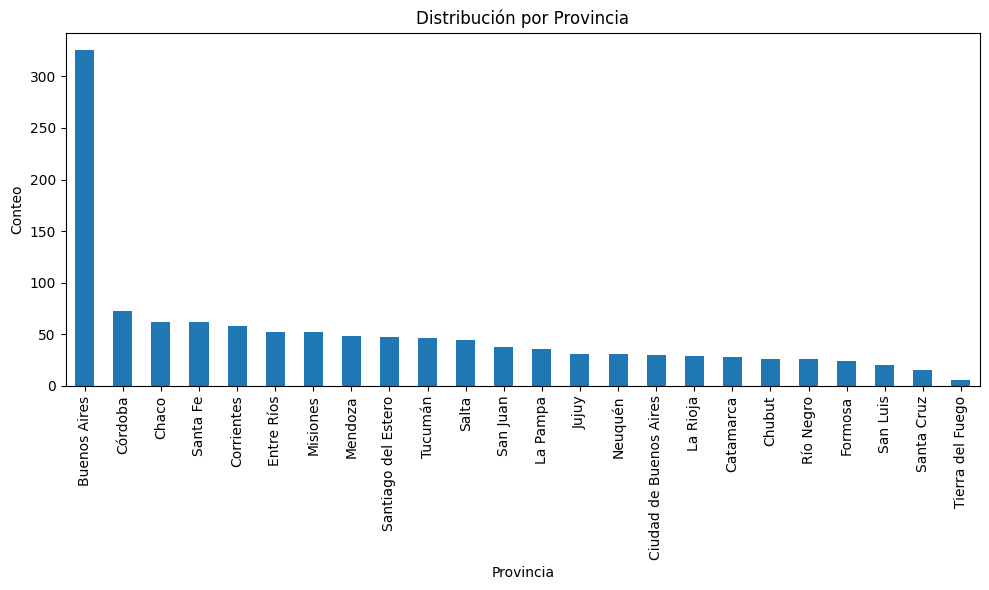

In [ ]:
plt.figure(figsize=(10, 6))
df_trayectoria_backup['provincia'].value_counts().plot(kind='bar')
plt.title('Distribución por Provincia')
plt.xlabel('Provincia')
plt.ylabel('Conteo')
plt.tight_layout()
plt.show()

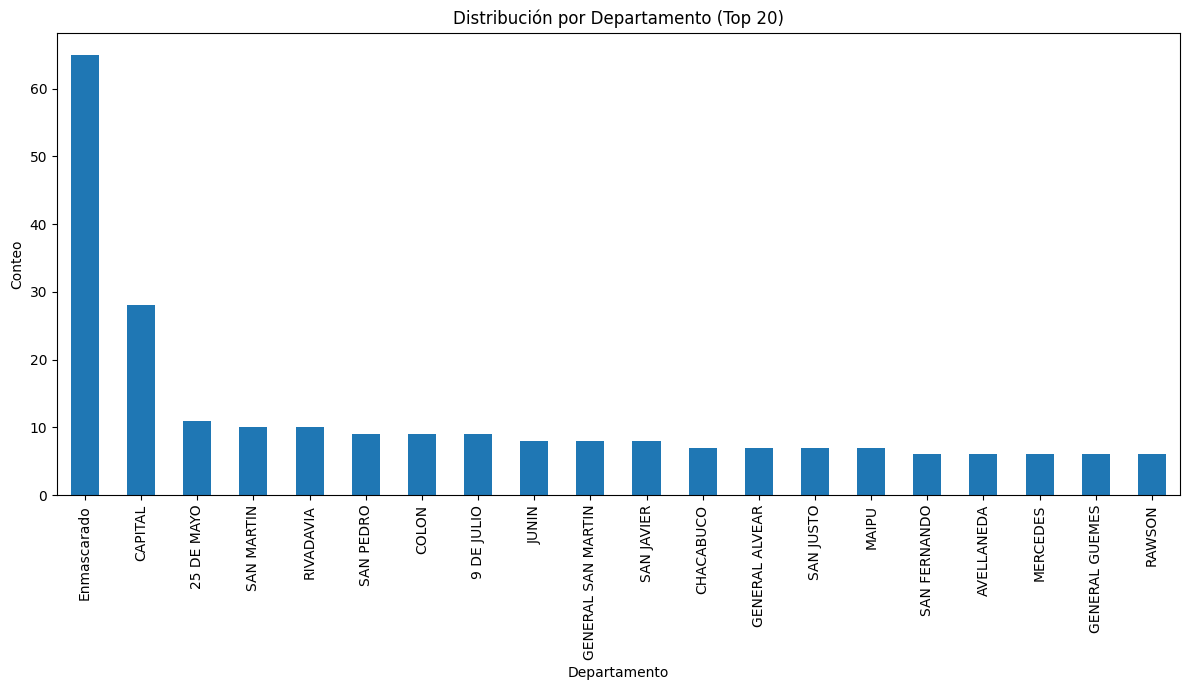

In [ ]:
plt.figure(figsize=(12, 7))
df_trayectoria_backup['Departamento'].value_counts().head(20).plot(kind='bar') # Display top 20 for readability
plt.title('Distribución por Departamento (Top 20)')
plt.xlabel('Departamento')
plt.ylabel('Conteo')
plt.tight_layout()
plt.show()

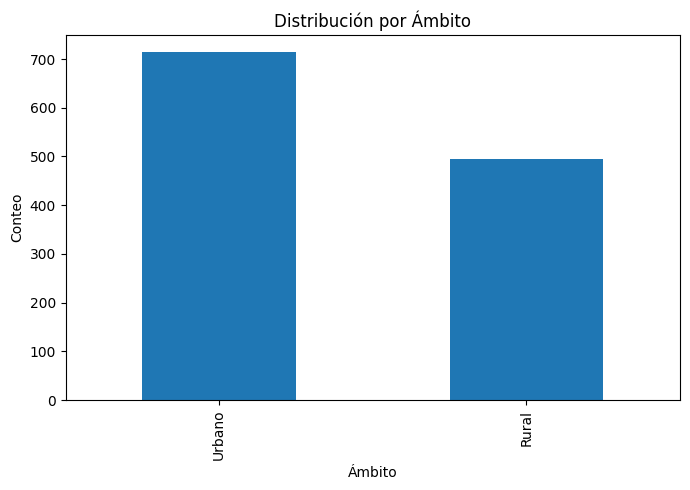

In [ ]:
plt.figure(figsize=(7, 5))
df_trayectoria_backup['ambito'].value_counts().plot(kind='bar')
plt.title('Distribución por Ámbito')
plt.xlabel('Ámbito')
plt.ylabel('Conteo')
plt.tight_layout()
plt.show()

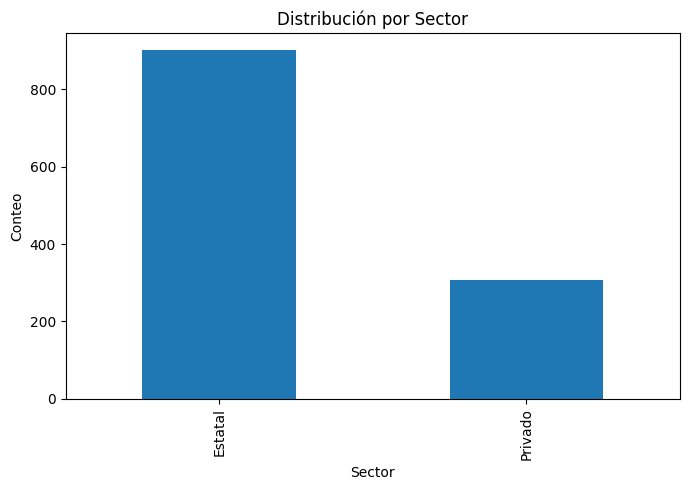

In [ ]:
plt.figure(figsize=(7, 5))
df_trayectoria_backup['sector'].value_counts().plot(kind='bar')
plt.title('Distribución por Sector')
plt.xlabel('Sector')
plt.ylabel('Conteo')
plt.tight_layout()
plt.show()

In [ ]:
#Variables numéricas
df_trayectoria_backup.describe()

,primaria_egresados,primaria_m_egresados,secundaria_egresados,secundaria_m_egresados
count,1209.000000,1209.000000,1209.000000,1209.000000
mean,607.819686,298.864351,359.308519,195.156328
std,1296.858307,634.596840,755.182348,404.503215
min,0.000000,0.000000,0.000000,0.000000
25%,86.000000,42.000000,45.000000,25.000000
50%,196.000000,95.000000,108.000000,60.000000
75%,524.000000,257.000000,301.000000,163.000000
max,19090.000000,9272.000000,11580.000000,6015.000000


In [ ]:
df_trayectoria_backup.select_dtypes(include=np.number).corr()

,primaria_egresados,primaria_m_egresados,secundaria_egresados,secundaria_m_egresados
primaria_egresados,1.000000,0.999591,0.949165,0.941920
primaria_m_egresados,0.999591,1.000000,0.952405,0.945952
secundaria_egresados,0.949165,0.952405,1.000000,0.998287
secundaria_m_egresados,0.941920,0.945952,0.998287,1.000000


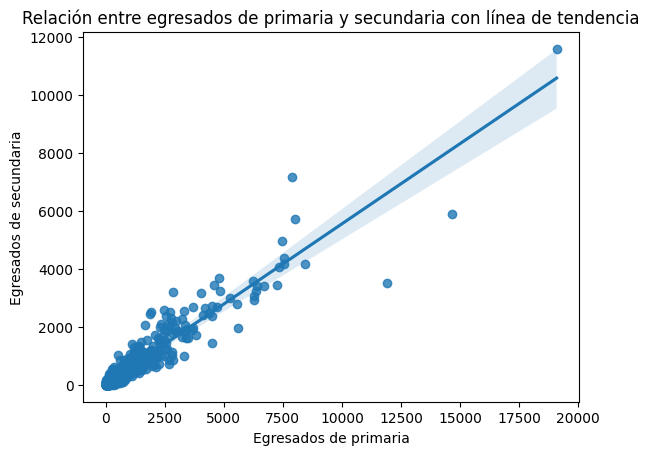

In [ ]:
sns.regplot(x='primaria_egresados', y='secundaria_egresados', data=df_trayectoria_backup)
plt.title('Relación entre egresados de primaria y secundaria con línea de tendencia')
plt.xlabel('Egresados de primaria')
plt.ylabel('Egresados de secundaria')
plt.show()

In [ ]:
df_egresados_por_sector = df_trayectoria_backup.groupby('sector')[['primaria_egresados', 'primaria_m_egresados', 'secundaria_egresados', 'secundaria_m_egresados']].mean()
display(df_egresados_por_sector)

,primaria_egresados,primaria_m_egresados,secundaria_egresados,secundaria_m_egresados
sector,,,,
Estatal,599.562708,291.72475,305.491676,162.397336
Privado,631.974026,319.75000,516.740260,290.987013


# 5. Hallazgos iniciales

En primer lugar podemos observar que un gran porcentaje de los egresados se ubican en la provincia de Buenos Aires y que la mayor cantidad de ellos pertenecen al sector de gestión estatal. Por otro lado, hay una correlación positiva entre los egresados de primaria y los egresados de secundaria indicando que a mayor cantidad de egresados de primaria en una provincia mayor cantidad de egresados de secundaria en la misma provincia.
Por otro lado cuando se observan los promedios de egresados se encuentra que casi 600 egresdos de primaria pertenecen al sector estatal mientras que 632 pertenecen al sector privado.
En cuanto al nivel secundario se observa que apenas 305 son egresados de sector estatal mientras que 517 son de sector privado.

# 6 Problema de abordaje con Data Science

Teniendo en cuenta la diversidad de los datos y las características de la población, sería interesante observar que patrones se presentan en cuanto a los egresados de los niveles primario y secundario del país, ¿Hay grupos similares en las distintas provincias o hay diferencias más marcadas?
Por tal motivo sería interesante plantear un modelo de clustering para observar que patrones se generan en los egresados del país ya que no existe una variable objetivo.

Este modelo es pertinente ya que no se cuenta con una variable objetivo y no se trata de realizar una predicción sino de agrupar los datos en grupos que permitan a futuro plantear acciones específicas para cada grupo.

### 6.1 Balanceo del dataset por provincia

In [ ]:
# Contar el número de ocurrencias por provincia
province_counts = df_trayectoria_backup['provincia'].value_counts()

# Identificar la provincia con la mayor cantidad de registros (Buenos Aires)
most_frequent_province = province_counts.index[0]

# Identificar la segunda provincia con más registros y su conteo
second_most_frequent_count = province_counts.iloc[1]

print(f"La provincia con más registros es '{most_frequent_province}' con {province_counts.iloc[0]} registros.")
print(f"La segunda provincia con más registros tiene {second_most_frequent_count} registros.")


La provincia con más registros es 'Buenos Aires' con 326 registros.
La segunda provincia con más registros tiene 72 registros.


In [ ]:
# Separar la provincia de Buenos Aires y las demás provincias
df_buenos_aires = df_trayectoria_backup[df_trayectoria_backup['provincia'] == most_frequent_province]
df_other_provinces = df_trayectoria_backup[df_trayectoria_backup['provincia'] != most_frequent_province]

# Submuestrear 'Buenos Aires' para que tenga el mismo número de registros que la segunda provincia más frecuente
df_buenos_aires_sampled = df_buenos_aires.sample(n=second_most_frequent_count, random_state=42)

# Concatenar el DataFrame submuestreado de Buenos Aires con las otras provincias
df_trayectoria_balanced = pd.concat([df_buenos_aires_sampled, df_other_provinces])

# Verificar la nueva distribución de provincias
print("Nueva distribución de registros por provincia después del balanceo:")
display(df_trayectoria_balanced['provincia'].value_counts())

# Mostrar las nuevas dimensiones del DataFrame balanceado
print("Nuevas dimensiones del DataFrame balanceado:")
display(df_trayectoria_balanced.shape)

Nueva distribución de registros por provincia después del balanceo:


,count
provincia,
Buenos Aires,72
Córdoba,72
Chaco,62
Santa Fe,62
Corrientes,58
Entre Ríos,52
Misiones,52
Mendoza,48
Santiago del Estero,47


Nuevas dimensiones del DataFrame balanceado:


(955, 8)

Sobre el DataFrame df_trayectoria_backup aplicamos un undersampling sobre la segunda categoría más recurrente para que quede más equilibrada la distribución de observaciones y creamos un nuevo data frame llamado `df_trayectoria_balanced`. Éste tiene una distribución de provincias más equitativa, que nos va a permitir tener un menor sesgo a la hora de realizar un analisis de clusters.

### 6.2 Codificación de variables categóricas,  Feature Encoding

In [ ]:
# Seleccionar las columnas categóricas para codificar
categorical_cols = ['provincia', 'ambito', 'sector']

# Aplicar One-Hot Encoding
df_trayectoria_encoded = pd.get_dummies(df_trayectoria_balanced, columns=categorical_cols, drop_first=False)

print("Dimensiones del DataFrame después de la codificación:", df_trayectoria_encoded.shape)
print("Primeros registros del DataFrame codificado:")
display(df_trayectoria_encoded.head())


Dimensiones del DataFrame después de la codificación: (955, 33)
Primeros registros del DataFrame codificado:


,Departamento,primaria_egresados,primaria_m_egresados,secundaria_egresados,secundaria_m_egresados,provincia_Buenos Aires,provincia_Catamarca,provincia_Chaco,provincia_Chubut,provincia_Ciudad de Buenos Aires,...,provincia_San Luis,provincia_Santa Cruz,provincia_Santa Fe,provincia_Santiago del Estero,provincia_Tierra del Fuego,provincia_Tucumán,ambito_Rural,ambito_Urbano,sector_Estatal,sector_Privado
234,PILA,55,36,49,24,True,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
110,FLORENTINO AMEGHINO,102,49,68,41,True,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
249,RAMALLO,526,238,373,206,True,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
9,ADOLFO GONZALES CHAVES,92,48,36,23,True,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
93,Enmascarado,368,187,603,304,True,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True


Ahora codificamos las variables categóricas con One hot encoding para normalizar los datos y prepararlos para la selección de características.

# 7. Selección de características, Feature Selection

Para observar como se distribuyen en grupos los egresados teniendo en cuenta la jurisdicción de pertenencia y el ámbito y sector de gestión al que pertenecen tomamos las variables de egresados de primaria, egresados de primaria mujeres, egresados de secundaria, egresados de secundaria mujeres, provincia, ámbito y sector codificados.

In [ ]:
# Identificar las columnas numéricas de egresados
numerical_egresados_cols = ['primaria_egresados', 'primaria_m_egresados', 'secundaria_egresados', 'secundaria_m_egresados']

# Identificar las columnas one-hot encoded de las variables categóricas
one_hot_cols = [col for col in df_trayectoria_encoded.columns if col.startswith(('provincia_', 'ambito_', 'sector_'))]

# Combinar todas las columnas seleccionadas
selected_features = numerical_egresados_cols + one_hot_cols

# Aplicar la selección de características directamente en df_trayectoria_encoded
df_trayectoria_encoded = df_trayectoria_encoded[selected_features]

print("Dimensiones del DataFrame después de la selección de características:", df_trayectoria_encoded.shape)
print("Primeros registros del DataFrame con características seleccionadas:")
display(df_trayectoria_encoded.head())

Dimensiones del DataFrame después de la selección de características: (955, 32)
Primeros registros del DataFrame con características seleccionadas:


,primaria_egresados,primaria_m_egresados,secundaria_egresados,secundaria_m_egresados,provincia_Buenos Aires,provincia_Catamarca,provincia_Chaco,provincia_Chubut,provincia_Ciudad de Buenos Aires,provincia_Corrientes,...,provincia_San Luis,provincia_Santa Cruz,provincia_Santa Fe,provincia_Santiago del Estero,provincia_Tierra del Fuego,provincia_Tucumán,ambito_Rural,ambito_Urbano,sector_Estatal,sector_Privado
234,55,36,49,24,True,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
110,102,49,68,41,True,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
249,526,238,373,206,True,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
9,92,48,36,23,True,False,False,False,False,False,...,False,False,False,False,False,False,False,True,True,False
93,368,187,603,304,True,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,True


# 7.1 Análisis de Componentes Principales (PCA)

Para asegurarnos que la cantidad de columnas que tiene el dataframe no esté afectando la variación aplicamos una prueba de analisis de componentes principales para efectivamente comprobar que las variables seleccionadas son pertinentes.

Varianza explicada por cada componente principal:
Componente 1: 0.9680 (96.80%)
Componente 2: 0.0318 (3.18%)
Componente 3: 0.0001 (0.01%)
Componente 4: 0.0001 (0.01%)
Componente 5: 0.0000 (0.00%)
Componente 6: 0.0000 (0.00%)
Componente 7: 0.0000 (0.00%)
Componente 8: 0.0000 (0.00%)
Componente 9: 0.0000 (0.00%)
Componente 10: 0.0000 (0.00%)
Componente 11: 0.0000 (0.00%)
Componente 12: 0.0000 (0.00%)
Componente 13: 0.0000 (0.00%)
Componente 14: 0.0000 (0.00%)
Componente 15: 0.0000 (0.00%)
Componente 16: 0.0000 (0.00%)
Componente 17: 0.0000 (0.00%)
Componente 18: 0.0000 (0.00%)
Componente 19: 0.0000 (0.00%)
Componente 20: 0.0000 (0.00%)
Componente 21: 0.0000 (0.00%)
Componente 22: 0.0000 (0.00%)
Componente 23: 0.0000 (0.00%)
Componente 24: 0.0000 (0.00%)
Componente 25: 0.0000 (0.00%)
Componente 26: 0.0000 (0.00%)
Componente 27: 0.0000 (0.00%)
Componente 28: 0.0000 (0.00%)
Componente 29: 0.0000 (0.00%)
Componente 30: 0.0000 (0.00%)
Componente 31: 0.0000 (0.00%)
Componente 32: 0.0000 (0.00%

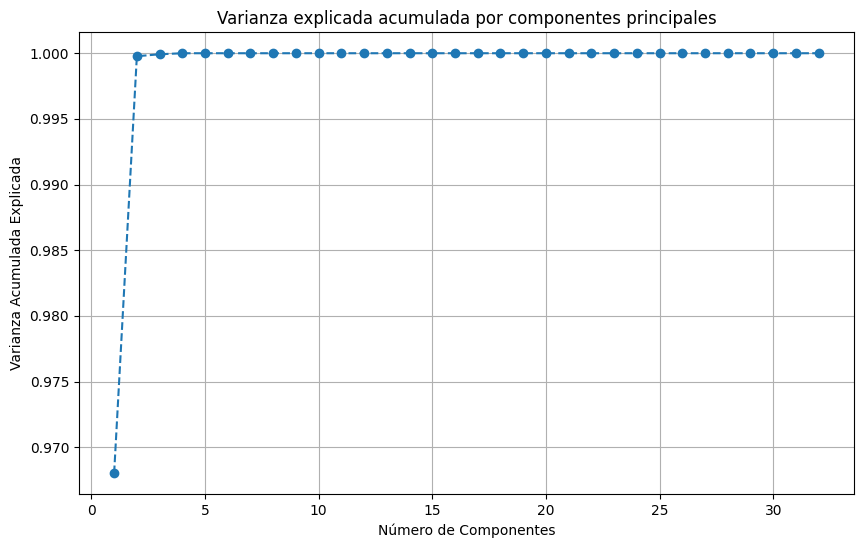


Número de componentes para retener (explicando >95% de varianza): 1

Dimensiones del DataFrame después de PCA: (955, 1)
Primeros registros del DataFrame PCA:


,PC_1
0,-584.673036
1,-530.720576
2,41.899657
3,-556.338545
4,14.397097


In [ ]:
from sklearn.decomposition import PCA

# Inicializar PCA (podemos especificar n_components después de analizar la varianza explicada)
pca = PCA()

# Ajustar PCA al DataFrame codificado
pca.fit(df_trayectoria_encoded)

# Calcular la varianza explicada por cada componente
explained_variance_ratio = pca.explained_variance_ratio_

print("Varianza explicada por cada componente principal:")
for i, ratio in enumerate(explained_variance_ratio):
    print(f"Componente {i+1}: {ratio:.4f} ({ratio*100:.2f}%)")

# Calcular la varianza acumulada
cumulative_variance = np.cumsum(explained_variance_ratio)
print("\nVarianza acumulada:")
for i, cum_ratio in enumerate(cumulative_variance):
    print(f"Hasta Componente {i+1}: {cum_ratio:.4f} ({cum_ratio*100:.2f}%)")

# Graficar la varianza explicada acumulada
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
plt.title('Varianza explicada acumulada por componentes principales')
plt.xlabel('Número de Componentes')
plt.ylabel('Varianza Acumulada Explicada')
plt.grid(True)
plt.show()

# Decidir el número de componentes basado en la varianza explicada acumulada (ejemplo: > 95%)
n_components_to_retain = np.where(cumulative_variance >= 0.95)[0][0] + 1
print(f"\nNúmero de componentes para retener (explicando >95% de varianza): {n_components_to_retain}")

# Aplicar PCA con el número óptimo de componentes
pca_final = PCA(n_components=n_components_to_retain)
df_pca = pca_final.fit_transform(df_trayectoria_encoded)

# Convertir el resultado de PCA a un DataFrame para facilitar el manejo
df_pca = pd.DataFrame(df_pca, columns=[f'PC_{i+1}' for i in range(n_components_to_retain)])

print("\nDimensiones del DataFrame después de PCA:", df_pca.shape)
print("Primeros registros del DataFrame PCA:")
display(df_pca.head())

Realizamos una prueba de Analisis de componentes Principales para observar que componentes del dataframe son los que tienen más influencia en la variación de los datos y a partir de ellos avanzar con la definición optima de los grupos para aplicar el modelo de K Means.
Además se crea un nuevo dataframe llamado dataframe pca para poder manejar los datos con mayor facilidad.

### 7.2 Determinación del número óptimo de clusters (Método del Codo)

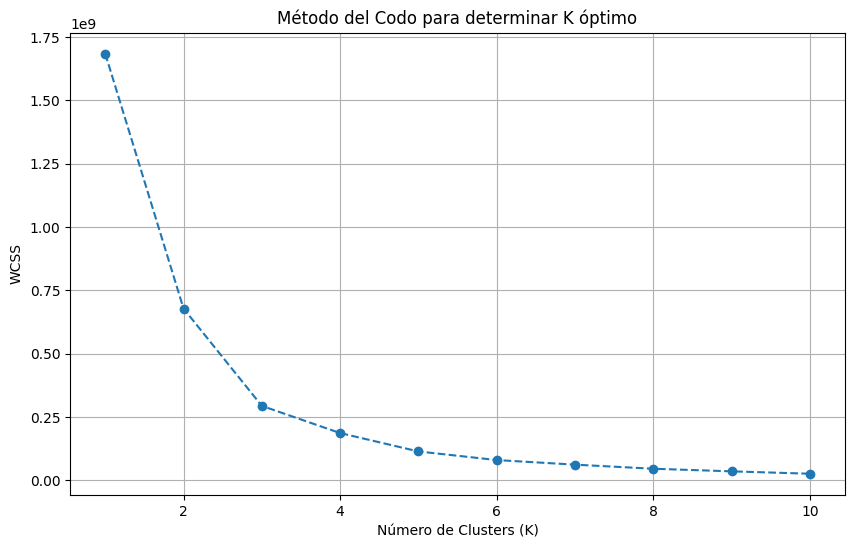

In [ ]:
from sklearn.cluster import KMeans

wcss = [] # Suma de cuadrados intra-cluster

# Probar diferentes números de clusters de 1 a 10
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(df_pca)
    wcss.append(kmeans.inertia_)

# Graficar el método del codo
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Método del Codo para determinar K óptimo')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('WCSS') # Within-Cluster Sum of Squares
plt.grid(True)
plt.show()

Aplicamos el método del codo para la determinación óptima de los grupos de clusters para la aplicación del modelo de K Means.

# 8 Aplicación del modelo de K Means

A partir de la prueba del metodo del codo definimos en 4 grupos los clusters sobre los que va a trabajar el modelo y aplicamos la prueba de K Means.

In [ ]:
from sklearn.cluster import KMeans

k = 4 # Número óptimo de clusters determinado por el método del codo

kmeans_model = KMeans(n_clusters=k, init='k-means++', max_iter=300, n_init=10, random_state=42)
kmeans_model.fit(df_pca)

# Asignar las etiquetas de cluster a cada punto de datos
cluster_labels = kmeans_model.labels_

# Añadir las etiquetas de cluster al DataFrame PCA
df_pca['cluster'] = cluster_labels

print(f"Se han creado {k} clusters.")
print("Distribución de los puntos de datos por cluster:")
display(df_pca['cluster'].value_counts())

print("Primeros registros del DataFrame PCA con las etiquetas de cluster:")
display(df_pca.head())

Se han creado 4 clusters.
Distribución de los puntos de datos por cluster:


,count
cluster,
0,782
3,130
2,34
1,9


Primeros registros del DataFrame PCA con las etiquetas de cluster:


,PC_1,cluster
0,-584.673036,0
1,-530.720576,0
2,41.899657,0
3,-556.338545,0
4,14.397097,0


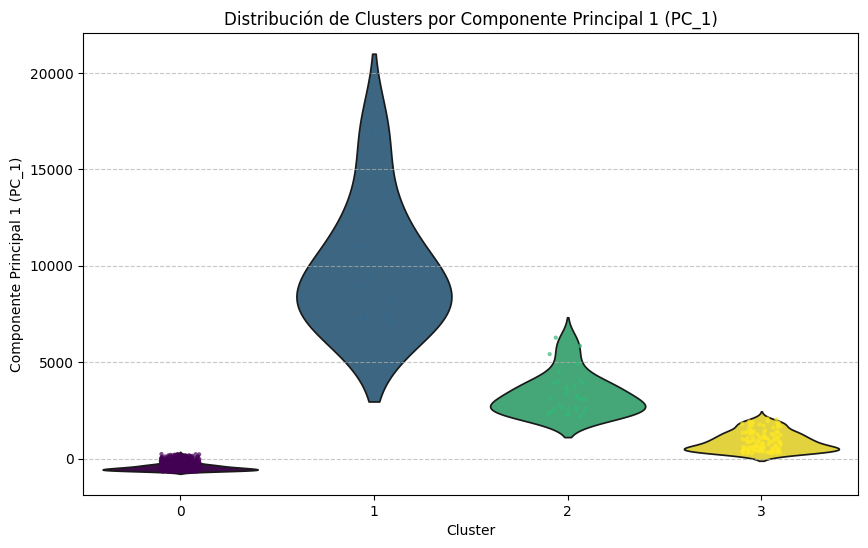

In [ ]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='cluster', y='PC_1', data=df_pca, inner=None, palette='viridis', hue='cluster', legend=False)
sns.stripplot(x='cluster', y='PC_1', data=df_pca, jitter=True, hue='cluster', palette='viridis', size=3, alpha=0.7, legend=False)
plt.title('Distribución de Clusters por Componente Principal 1 (PC_1)')
plt.xlabel('Cluster')
plt.ylabel('Componente Principal 1 (PC_1)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Realizamos un gráfico de violín, con los puntos individuales superpuestos, que nos permite ver la densidad y la distribución de los valores de `PC_1` para cada cluster. Observamos que:

*   **Cluster 0** tiene una distribución amplia y abarca la mayor parte de los puntos, lo cual es consistente con su gran tamaño.
*   **Cluster 3** se encuentra en un rango de valores diferente de `PC_1`.
*   **Cluster 1 y 2** son los más pequeños y tienen distribuciones más concentradas.

Esto nos lleva a pensar en realizar un analisis de las características.

# 8.1 Evaluación del modelo

In [ ]:
# Primero, aseguramos que df_trayectoria_encoded tiene el índice correcto para la unión con df_pca
df_trayectoria_encoded.reset_index(drop=True, inplace=True)
df_pca.reset_index(drop=True, inplace=True)

# Unir las etiquetas de cluster al DataFrame original con las características seleccionadas
df_clustered_features = pd.concat([df_trayectoria_encoded, df_pca['cluster']], axis=1)

# Calcular el promedio de las características por cada cluster
cluster_characteristics = df_clustered_features.groupby('cluster').mean()
display(cluster_characteristics)

,primaria_egresados,primaria_m_egresados,secundaria_egresados,secundaria_m_egresados,provincia_Buenos Aires,provincia_Catamarca,provincia_Chaco,provincia_Chubut,provincia_Ciudad de Buenos Aires,provincia_Corrientes,...,provincia_San Luis,provincia_Santa Cruz,provincia_Santa Fe,provincia_Santiago del Estero,provincia_Tierra del Fuego,provincia_Tucumán,ambito_Rural,ambito_Urbano,sector_Estatal,sector_Privado
cluster,,,,,,,,,,,,,,,,,,,,,
0,200.782609,99.404092,112.854220,63.469309,0.075448,0.033248,0.072890,0.028133,0.000000,0.067775,...,0.023018,0.016624,0.062660,0.054987,0.005115,0.044757,0.528133,0.471867,0.762148,0.237852
1,8419.222222,4130.111111,4306.222222,2318.111111,0.111111,0.000000,0.111111,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.222222,0.000000,0.000000,0.111111,0.000000,1.000000,0.777778,0.222222
2,3089.764706,1511.205882,1787.588235,965.088235,0.176471,0.000000,0.000000,0.029412,0.088235,0.029412,...,0.029412,0.000000,0.058824,0.029412,0.000000,0.058824,0.000000,1.000000,0.735294,0.264706
3,1205.392308,593.538462,726.438462,395.661538,0.046154,0.015385,0.030769,0.023077,0.207692,0.030769,...,0.007692,0.015385,0.069231,0.023077,0.015385,0.061538,0.030769,0.969231,0.676923,0.323077


Creamos un DataFrame de `cluster_characteristics` que nos muestra el valor promedio de cada característica (tanto las numéricas de egresados como las binarias de las provincias, ámbito y sector) para cada uno de los 4 clusters. Al analizar estas medias, podemos identificar qué combinación de atributos define a cada grupo. Por ejemplo:

*   Un valor alto en `primaria_egresados` o `secundaria_egresados` indicaría que ese cluster representa zonas con muchos egresados.
*   Un valor cercano a 1 en `provincia_Buenos Aires` (o cualquier otra provincia codificada) sugiere que ese cluster está fuertemente asociado a esa provincia en particular.
*   De manera similar, valores altos para `ambito_Rural` o `sector_Estatal` indican la predominancia de esas características en el cluster.

Para analizar la relación entre las provincias y los clústeres, creamos un heatmap o mapa de calor, que nos muestre la proporción de cada provincia dentro de cada clúster. Esto nos permitirá identificar si hay provincias predominantes en ciertos clústeres o si la distribución es más uniforme.

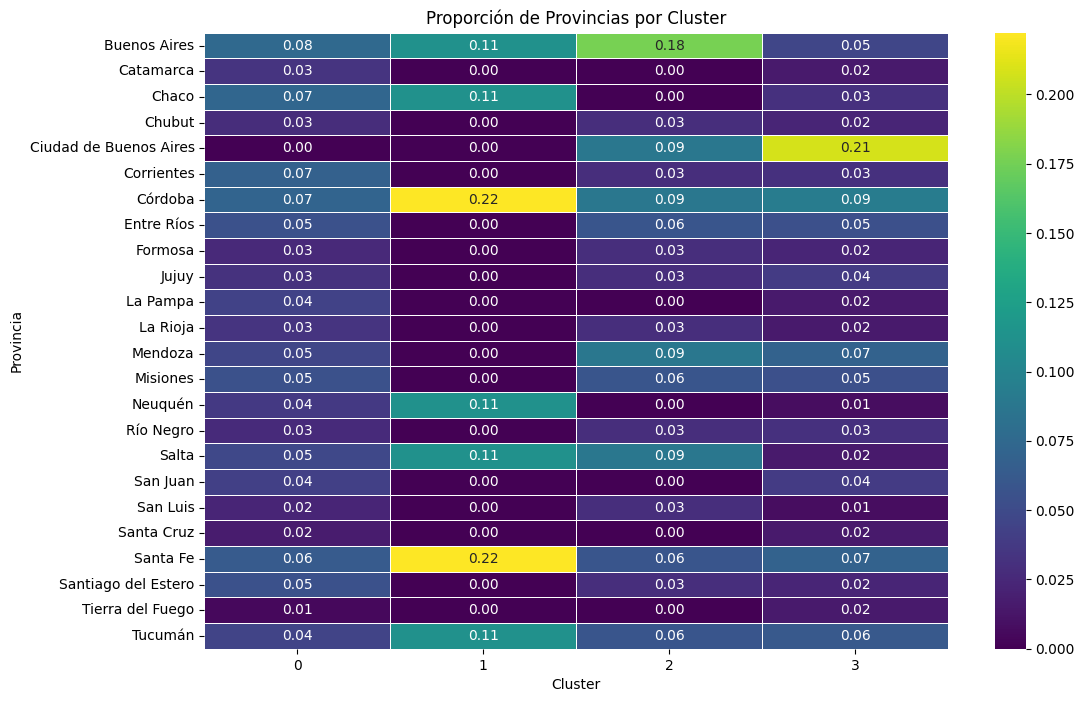

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Asegurarse de que los índices coincidan para la unión
df_trayectoria_balanced.reset_index(drop=True, inplace=True)
df_pca.reset_index(drop=True, inplace=True)

# Unir el DataFrame original balanceado con las etiquetas de cluster
df_original_with_clusters = pd.concat([df_trayectoria_balanced, df_pca['cluster']], axis=1)

# Calcular la tabla de contingencia de 'provincia' y 'cluster'
contingency_table = pd.crosstab(df_original_with_clusters['provincia'], df_original_with_clusters['cluster'])

# Normalizar la tabla para obtener proporciones por cluster (suma de columnas = 1)
# axis=0 para normalizar por columna (cada columna suma 1, representando la distribución de provincias dentro de un cluster)
proportions = contingency_table.div(contingency_table.sum(axis=0), axis=1)

plt.figure(figsize=(12, 8))
sns.heatmap(proportions, annot=True, fmt=".2f", cmap="viridis", linewidths=.5)
plt.title('Proporción de Provincias por Cluster')
plt.xlabel('Cluster')
plt.ylabel('Provincia')
plt.show()

Cómo podemos observar del mapa de calor se desprende que en el cluster 0 de grupos hay una mayor diversidad de observaciones incluyendo las distintas provincias. Mientras tanto en el cluster 1 pesan más las provincias de Córdoba y Santa Fe, por encima de las demás. En el cluster 2 hay una fuerte presencia de la provincia de Buenos Aires. Y por último en el cluster 3 predomina en el grupo la cantidad de observaciones de la Ciudad de Buenos Aires.

Esto nos lleva a pensar en la necesidad de ajustar el modelo, si bien se generan claramente 4 grupos, parece haber grupos donde hay provincias que representan la mayoría de las observaciones en algunos y no llegan a tener una diversidad más homogenea

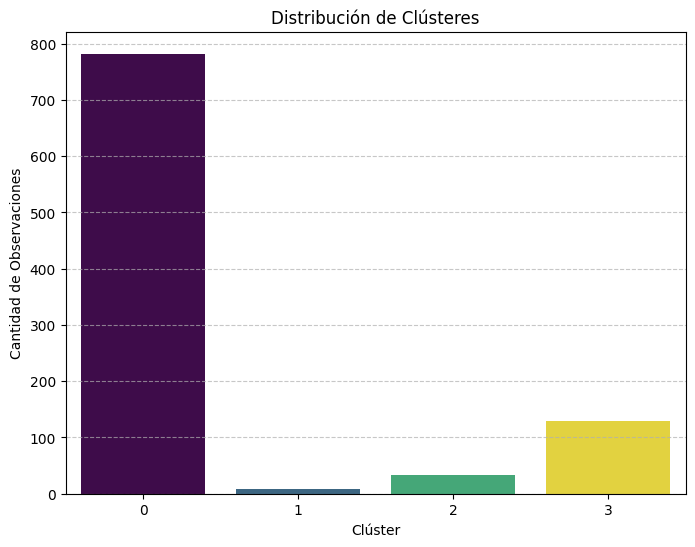

In [ ]:
plt.figure(figsize=(8, 6))
sns.countplot(x='cluster', data=df_pca, palette='viridis', hue='cluster', legend=False)
plt.title('Distribución de Clústeres')
plt.xlabel('Clúster')
plt.ylabel('Cantidad de Observaciones')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Para visualizar la composición y distribución de los clusters realizamos un gráfico de barras donde vemos que el cluster 0 tiene una distribución mucho mayor que los demás lo que nos hace pensar que habría que ajustar el dataset.

# 9 Comunicación de resultados y conclusiones.

A partir del modelo de K Means realizamos un analisis de clusters que estableció 4 clusters para conformar los grupos con el dataframe. Lo que ocurrió al llevar adelante este modelo fue que la presencia de varias observaciones de provincias que tienen mayor peso en la base de datos afectó la construcción del modelo. Esto lo pudimos observar a la hora de presentar el mapa de calor y el gráfico de barras de la distribución de los clusters, presentandose un cluster 0 con una cantidad mucho mayor que los demás de observaciones.

Por lo tanto, se requiere realizar ajustes al modelo que contribuyan a generar una distribución más homogenea de los clusters y permitan conformar grupos con menor amplitud en su diversidad.

# 10 Propuestas de implementación o mejora

Si bien el modelo nos permitió conformar grupos de manera clara se hace necesario realizar ajustes para mejorar la capacidad de conformar los grupos pero la posibilidad de implementarlos para focalizar políticas públicas educativas según la necesidad de los distintos grupos. Por poner un ejemplo las necesidades del cluster 0 con mayor peso en la provincia de buenos aires son sustancialmente distintas que las que puede tener el cluster 3 que integra una mayor diversidad de provincias y donde las necesidades pueden ser diferentes.

En resumen, considerando un ajuste del modelo en función de lograr una clusterización más precisa puede constituirse en una herramienta de gran utilidad para la aplicación de políticas educativas específicas.